# Semantic Analysis

In [1]:
# ==============================================================================
# === 0 INSTALLATION CORRECTIONS
# ==============================================================================
!pip uninstall -y protobuf
!pip install protobuf==3.20.3

Found existing installation: protobuf 6.33.0
Uninstalling protobuf-6.33.0:
  Successfully uninstalled protobuf-6.33.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
tensorflow-metadata 1.17.2 requires protobuf>=4.25.2; pyth

In [2]:
# ==============================================================================
# === 1.1 INSTALLATIONS
# ==============================================================================
print("Installing required packages...")
!pip install sentence-transformers -q
!pip install transformers accelerate -q
!pip install scikit-learn seaborn -q
print("Installations complete.")

Installing required packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 72.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency confli

In [3]:
# ==============================================================================
# === 1.2 IMPORTS
# ==============================================================================
import re
import os
import logging
import pandas as pd
import numpy as np
import torch
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# For Semantic Textual Similarity (STS)
from sentence_transformers import SentenceTransformer, util

# For Natural Language Inference (NLI)
from transformers import pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

2025-12-21 04:21:51.439581: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766290911.622456      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766290911.673177      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
# ==============================================================================
# === 2. CONFIGURATION & DATA LOADING
# ==============================================================================

class AnalysisConfig:
    POS_DATA_FILE = "/kaggle/input/lrec-tcs-attack-support/sentencePair.txt"
    NEG_DATA_FILE = "/kaggle/input/lrec-tcs-attack-support/sentencePair_neg.txt"
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    NLI_SAMPLE_SIZE = 2000 # NLI is slow, so we sample.
    STS_MODEL = 'all-MiniLM-L6-v2' # Fast and effective for similarity
    NLI_MODEL = 'facebook/bart-large-mnli' # Good zero-shot NLI model

# Setup basic logging
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
if not logger.handlers:
    stream_handler = logging.StreamHandler()
    stream_handler.setFormatter(formatter)
    logger.addHandler(stream_handler)

def parse_lrec_line(line: str):
    """Parses a single line from the LREC dataset files."""
    parts = line.strip().split("\t")
    fname_indices = [i for i, p in enumerate(parts) if p.endswith(".txt")]
    if len(fname_indices) != 2: return None
    try:
        sentpair_id = int(parts[0])
        sent1 = " ".join(parts[fname_indices[0] + 2 : fname_indices[1]]).strip('"')
        sent2 = " ".join(parts[fname_indices[1] + 2 : len(parts) - 2]).strip('"')
        label = parts[-1]
    except (ValueError, IndexError): return None
    return {"id": sentpair_id, "sent1": sent1, "sent2": sent2, "label": label}

def load_full_data(config: AnalysisConfig):
    """Loads and parses the full dataset from both positive and negative files."""
    logging.info("Loading full dataset for analysis...")
    rows = []
    for filepath in [config.POS_DATA_FILE, config.NEG_DATA_FILE]:
        if not os.path.exists(filepath):
            logging.error(f"Data file not found at '{filepath}'.")
            return None
        with open(filepath, "r", encoding="utf-8") as f:
            for line in f:
                if parsed := parse_lrec_line(line): rows.append(parsed)
    df = pd.DataFrame(rows)
    label_map = {"SUPPORT": 0, "ATTACK": 1, "NO_REL": 2}
    df["label_id"] = df["label"].map(label_map)
    df = df.dropna(subset=['id', 'sent1', 'sent2', 'label_id', 'label'])
    logging.info(f"Full dataset loaded. Total samples: {len(df)}")
    return df.reset_index(drop=True)

In [5]:
# ==============================================================================
# === 3. SEMANTIC TEXTUAL SIMILARITY (STS) ANALYSIS
# ==============================================================================

def perform_semantic_similarity_analysis(df: pd.DataFrame, model_name: str, config: AnalysisConfig):
    """
    Calculates the cosine similarity between sent1 and sent2 for all pairs.
    This runs on the FULL dataset.
    """
    logger.info(f"\n" + "="*50)
    logger.info(f"--- Starting Semantic Textual Similarity (STS) Analysis ---")
    logger.info(f"Using model: {model_name}")
    
    # 1. Load a model specifically trained for STS
    model = SentenceTransformer(model_name, device=config.DEVICE)
    
    # 2. Get lists of sentences
    sentences1 = df['sent1'].tolist()
    sentences2 = df['sent2'].tolist()
    
    # 3. Generate embeddings in batches
    logger.info(f"Encoding {len(sentences1)} sentences for sent1...")
    embeddings1 = model.encode(sentences1, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
    
    logger.info(f"Encoding {len(sentences2)} sentences for sent2...")
    embeddings2 = model.encode(sentences2, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
    
    # 4. Calculate pairwise cosine similarity
    # We use util.cos_sim and take the diagonal for pair-wise scores
    logger.info("Calculating pairwise cosine similarities...")
    similarities = util.cos_sim(embeddings1, embeddings2)
    
    # Get the similarity score for each (s1[i], s2[i]) pair
    df['similarity_score'] = np.diag(similarities)
    
    # 5. Analyze and Plot the results
    logger.info("Analysis of similarity scores:")
    print(df['similarity_score'].describe())
    
    print("\nMean similarity by label:")
    print(df.groupby('label')['similarity_score'].mean())
    
    # Plot distribution of scores by label
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='label', y='similarity_score')
    plt.title('Semantic Similarity (STS) Score by True Label', fontsize=16)
    plt.xlabel('Label')
    plt.ylabel('Cosine Similarity Score')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
    logger.info("--- STS Analysis Complete ---")
    return df

In [6]:
# ==============================================================================
# === 4. NATURAL LANGUAGE INFERENCE (NLI) ANALYSIS
# ==============================================================================

def perform_nli_analysis(df_sample: pd.DataFrame, model_name: str, config: AnalysisConfig):
    """
    Performs NLI (as zero-shot classification) on a SAMPLE of the data.
    Classifies the (sent1, sent2) pair as entailment, contradiction, or neutral.
    """
    logger.info(f"\n" + "="*50)
    logger.info(f"--- Starting Natural Language Inference (NLI) Analysis ---")
    logger.info(f"Using model: {model_name} on a sample of {len(df_sample)} pairs.")
    
    # 1. Load the zero-shot classification pipeline
    # This pipeline is pre-trained on NLI tasks
    classifier = pipeline(
        "zero-shot-classification",
        model=model_name,
        device=0 if config.DEVICE.type == "cuda" else -1
    )
    
    # 2. Define NLI candidate labels
    # This is the crucial step: we frame our task in NLI terms.
    candidate_labels = ["entailment", "contradiction", "neutral"]
    
    # 3. Create a list of sequences (sent1) and hypotheses (sent2)
    sequences = df_sample['sent1'].tolist()
    hypotheses = df_sample['sent2'].tolist()
    
    # 4. Run the pipeline in batches
    # We must pass sent2 as the "hypothesis_template"
    logger.info("Running NLI zero-shot pipeline (this may take a few minutes)...")
    results = []
    
    # The zero-shot pipeline isn't easily batchable with *different* hypotheses.
    # We must iterate, but pipeline is smart about it.
    # An alternative, faster way:
    inputs = [f"{s1} {classifier.tokenizer.sep_token} {s2}" for s1, s2 in zip(sequences, hypotheses)]
    
    # Run in batches. batch_size=8 or 16 is good for a BART-Large model.
    for out in tqdm(classifier(inputs, candidate_labels=candidate_labels, batch_size=16), total=len(inputs)):
        results.append(out)

    # 5. Parse results and add to the sample DataFrame
    df_sample['nli_label'] = [res['labels'][0] for res in results]
    df_sample['nli_score'] = [res['scores'][0] for res in results]
    
    # 6. Analyze and Plot the results
    logger.info("NLI Classification Results:")
    
    # Show the mapping:
    print("\n--- Crosstab: True Label vs. NLI-Predicted Label ---")
    crosstab = pd.crosstab(df_sample['label'], df_sample['nli_label'])
    print(crosstab.to_markdown())
    
    # Plot a confusion matrix
    print("\nPlotting confusion matrix...")
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        df_sample['label'], 
        df_sample['nli_label'], 
        ax=ax, 
        cmap='Blues',
        normalize='true' # Show percentages
    )
    ax.set_title('Confusion Matrix: True Label vs. NLI-Predicted Label')
    plt.show()
    
    logger.info("--- NLI Analysis Complete ---")
    return df_sample

2025-12-21 04:22:11,595 - INFO - Using device: cuda
INFO:__main__:Using device: cuda
2025-12-21 04:22:12,080 - INFO - 
INFO:__main__:
2025-12-21 04:22:12,081 - INFO - --- Starting Semantic Textual Similarity (STS) Analysis ---
INFO:__main__:--- Starting Semantic Textual Similarity (STS) Analysis ---
2025-12-21 04:22:12,082 - INFO - Using model: all-MiniLM-L6-v2
INFO:__main__:Using model: all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/633 [00:00<?, ?it/s]

2025-12-21 04:22:45,857 - INFO - Encoding 40506 sentences for sent2...
INFO:__main__:Encoding 40506 sentences for sent2...


Batches:   0%|          | 0/633 [00:00<?, ?it/s]

2025-12-21 04:23:09,748 - INFO - Calculating pairwise cosine similarities...
INFO:__main__:Calculating pairwise cosine similarities...
2025-12-21 04:23:17,155 - INFO - Analysis of similarity scores:
INFO:__main__:Analysis of similarity scores:


count    40506.000000
mean         0.467134
std          0.204226
min         -0.108907
25%          0.319025
50%          0.484501
75%          0.623349
max          1.000001
Name: similarity_score, dtype: float64

Mean similarity by label:
label
ATTACK     0.553194
NO_REL     0.352495
SUPPORT    0.602332
Name: similarity_score, dtype: float32


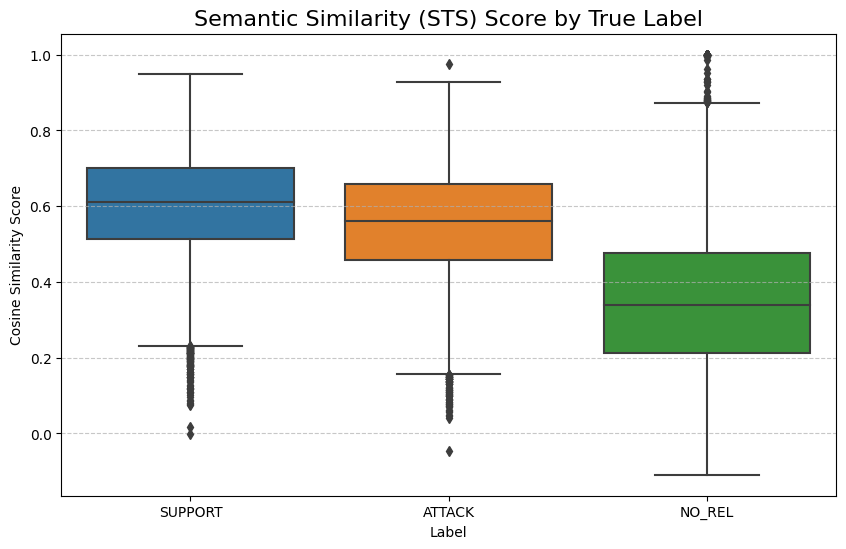

2025-12-21 04:23:17,400 - INFO - --- STS Analysis Complete ---
INFO:__main__:--- STS Analysis Complete ---
2025-12-21 04:23:17,834 - INFO - Creating a random sample of 2000 pairs for NLI analysis.
INFO:__main__:Creating a random sample of 2000 pairs for NLI analysis.
2025-12-21 04:23:17,838 - INFO - 
INFO:__main__:
2025-12-21 04:23:17,839 - INFO - --- Starting Natural Language Inference (NLI) Analysis ---
INFO:__main__:--- Starting Natural Language Inference (NLI) Analysis ---
2025-12-21 04:23:17,840 - INFO - Using model: facebook/bart-large-mnli on a sample of 2000 pairs.
INFO:__main__:Using model: facebook/bart-large-mnli on a sample of 2000 pairs.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0
2025-12-21 04:23:23,768 - INFO - Running NLI zero-shot pipeline (this may take a few minutes)...
INFO:__main__:Running NLI zero-shot pipeline (this may take a few minutes)...


  0%|          | 0/2000 [00:00<?, ?it/s]

2025-12-21 04:26:58,361 - INFO - NLI Classification Results:
INFO:__main__:NLI Classification Results:



--- Crosstab: True Label vs. NLI-Predicted Label ---
| label   |   contradiction |   entailment |   neutral |
|:--------|----------------:|-------------:|----------:|
| ATTACK  |             418 |           65 |         7 |
| NO_REL  |             739 |          214 |        12 |
| SUPPORT |             365 |          167 |        13 |

Plotting confusion matrix...


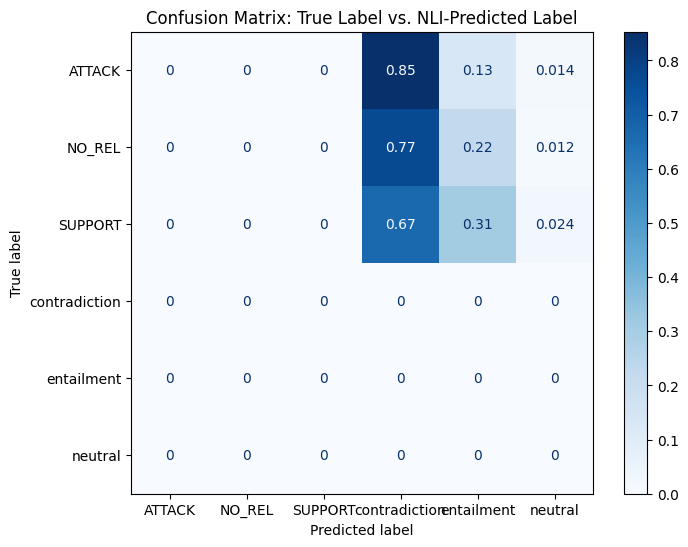

2025-12-21 04:26:58,658 - INFO - --- NLI Analysis Complete ---
INFO:__main__:--- NLI Analysis Complete ---
2025-12-21 04:26:59,292 - INFO - 
========== SEMANTIC ANALYSIS COMPLETE ==========
INFO:__main__:
========== SEMANTIC ANALYSIS COMPLETE ==========
2025-12-21 04:26:59,293 - INFO - Full results with similarity scores saved to 'results_with_semantic_similarity.csv'
INFO:__main__:Full results with similarity scores saved to 'results_with_semantic_similarity.csv'
2025-12-21 04:26:59,295 - INFO - NLI sample results saved to 'results_with_nli_sample.csv'
INFO:__main__:NLI sample results saved to 'results_with_nli_sample.csv'


In [7]:
# ==============================================================================
# === 5. MAIN EXECUTION
# ==============================================================================

if __name__ == '__main__':
    config = AnalysisConfig()
    logger.info(f"Using device: {config.DEVICE}")
    
    # 1. Load full dataset
    full_df = load_full_data(config)
    
    if full_df is not None:
        
        # --- Run STS Analysis ---
        # This is fast and runs on the full 40k+ dataset
        full_df_with_sts = perform_semantic_similarity_analysis(
            full_df.copy(), 
            config.STS_MODEL, 
            config
        )
        
        # --- Run NLI Analysis ---
        # This is slow and runs on a sample
        logger.info(f"Creating a random sample of {config.NLI_SAMPLE_SIZE} pairs for NLI analysis.")
        df_sample = full_df.sample(n=config.NLI_SAMPLE_SIZE, random_state=42)
        
        df_sample_with_nli = perform_nli_analysis(
            df_sample, 
            config.NLI_MODEL, 
            config
        )
        
        # 6. Save results
        full_df_with_sts.to_csv("results_with_semantic_similarity.csv", index=False)
        df_sample_with_nli.to_csv("results_with_nli_sample.csv", index=False)
        
        logger.info("\n========== SEMANTIC ANALYSIS COMPLETE ==========")
        logger.info("Full results with similarity scores saved to 'results_with_semantic_similarity.csv'")
        logger.info("NLI sample results saved to 'results_with_nli_sample.csv'")
        
    else:
        logger.error("Failed to load data. Exiting.")

In [8]:
# ==============================================================================
# === 4. NATURAL LANGUAGE INFERENCE (NLI) ANALYSIS with premise-hypothesis inputs
# ==============================================================================

def perform_nli_analysis2(df_sample: pd.DataFrame, model_name: str, config):
    """
    Performs TRUE Natural Language Inference (premise-hypothesis).
    Classifies (sent1, sent2) as entailment, contradiction, or neutral.
    """

    logger.info("\n" + "=" * 50)
    logger.info("--- Starting TRUE NLI Analysis ---")
    logger.info(f"Using model: {model_name} on {len(df_sample)} sentence pairs")

    # ------------------------------------------------------------------
    # 1. Load NLI model (NOT zero-shot)
    # ------------------------------------------------------------------
    nli_pipeline = pipeline(
        "text-classification",
        model=model_name,                 # e.g. facebook/bart-large-mnli
        device=0 if config.DEVICE.type == "cuda" else -1,
        return_all_scores=True
    )

    id2label = nli_pipeline.model.config.id2label
    logger.info(f"NLI labels: {id2label}")

    # ------------------------------------------------------------------
    # 2. Prepare premise-hypothesis inputs
    # BART NLI format:  premise </s></s> hypothesis
    # ------------------------------------------------------------------
    inputs = [
        f"{s1} </s></s> {s2}"
        for s1, s2 in zip(df_sample["sent1"], df_sample["sent2"])
    ]

    # ------------------------------------------------------------------
    # 3. Run inference
    # ------------------------------------------------------------------
    logger.info("Running NLI inference...")
    results = []

    for out in tqdm(
        nli_pipeline(inputs, batch_size=16),
        total=len(inputs)
    ):
        results.append(out)

    # ------------------------------------------------------------------
    # 4. Extract predictions
    # ------------------------------------------------------------------
    nli_labels = []
    nli_scores = []

    for res in results:
        scores = [x["score"] for x in res]
        best_idx = int(np.argmax(scores))
        nli_labels.append(id2label[best_idx])
        nli_scores.append(scores[best_idx])

    df_sample["nli_label"] = nli_labels
    df_sample["nli_score"] = nli_scores

    # ------------------------------------------------------------------
    # 5. Crosstab
    # ------------------------------------------------------------------
    print("\n--- Crosstab: True Label vs. NLI-Predicted Label ---")
    crosstab = pd.crosstab(
        df_sample["label"],
        df_sample["nli_label"]
    )
    print(crosstab.to_markdown())

    # ------------------------------------------------------------------
    # 6. Cross-space confusion matrix (Argument × NLI)
    # ------------------------------------------------------------------

    true_labels = ["ATTACK", "NO_REL", "SUPPORT"]
    pred_labels = ["contradiction", "entailment", "neutral"]
    
    # Build 3x3 matrix explicitly
    cm = pd.crosstab(
        df_sample["label"],
        df_sample["nli_label"]
    ).reindex(index=true_labels, columns=pred_labels, fill_value=0)
    
    # Normalize row-wise (like confusion matrix)
    cm_norm = cm.div(cm.sum(axis=1), axis=0)
    
    # Plot
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_norm, cmap="Blues")
    
    ax.set_xticks(np.arange(len(pred_labels)))
    ax.set_yticks(np.arange(len(true_labels)))
    
    ax.set_xticklabels(pred_labels)
    ax.set_yticklabels(true_labels)
    
    ax.set_xlabel("NLI-Predicted Label")
    ax.set_ylabel("True Argument Label")
    ax.set_title("Argument Relation vs NLI Prediction")

    # Annotate cells
    for i in range(len(true_labels)):
        for j in range(len(pred_labels)):
            ax.text(
                j, i,
                f"{cm_norm.iloc[i, j]:.2f}",
                ha="center",
                va="center",
                color="black"
            )
    
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()
    logger.info("--- NLI Analysis Complete ---")
    
    return df_sample



2025-12-21 04:26:59,414 - INFO - Creating random sample of 2000 pairs
INFO:__main__:Creating random sample of 2000 pairs
2025-12-21 04:26:59,418 - INFO - 
INFO:__main__:
2025-12-21 04:26:59,419 - INFO - --- Starting TRUE NLI Analysis ---
INFO:__main__:--- Starting TRUE NLI Analysis ---
2025-12-21 04:26:59,421 - INFO - Using model: facebook/bart-large-mnli on 2000 sentence pairs
INFO:__main__:Using model: facebook/bart-large-mnli on 2000 sentence pairs
Device set to use cuda:0
/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
2025-12-21 04:27:00,567 - INFO - NLI labels: {0: 'contradiction', 1: 'neutral', 2: 'entailment'}
INFO:__main__:NLI labels: {0: 'contradiction', 1: 'neutral', 2: 'entailment'}
2025-12-21 04:27:00,570 - INFO - Running NLI in

  0%|          | 0/2000 [00:00<?, ?it/s]


--- Crosstab: True Label vs. NLI-Predicted Label ---
| label   |   contradiction |   entailment |   neutral |
|:--------|----------------:|-------------:|----------:|
| ATTACK  |             185 |           25 |       280 |
| NO_REL  |             216 |           22 |       727 |
| SUPPORT |             121 |           41 |       383 |


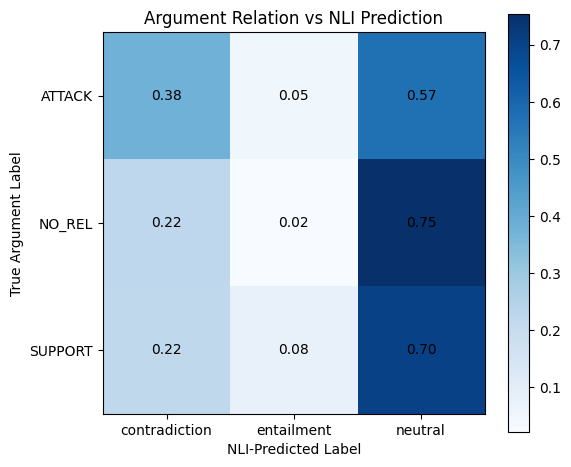

2025-12-21 04:28:19,256 - INFO - --- NLI Analysis Complete ---
INFO:__main__:--- NLI Analysis Complete ---


In [9]:
# ------------------------------------------------------------------
# Run NLI Analysis on a sample
# ------------------------------------------------------------------

logger.info(f"Creating random sample of {config.NLI_SAMPLE_SIZE} pairs")

df_sample = full_df.sample(
    n=config.NLI_SAMPLE_SIZE,
    random_state=42
).reset_index(drop=True)

df_sample_with_nli = perform_nli_analysis2(
    df_sample=df_sample,
    model_name=config.NLI_MODEL,   # e.g. "facebook/bart-large-mnli"
    config=config
)

# Save results
df_sample_with_nli.to_csv("results_with_nli_sample.csv", index=False)


In [10]:
# ==============================================================================
# === 6. NATURAL LANGUAGE INFERENCE (NLI) ANALYSIS (ZeroShot)
# ==============================================================================

def perform_nli_analysis3(df_sample: pd.DataFrame, model_name: str, config: AnalysisConfig):
    """
    Performs NLI (as zero-shot classification) on a SAMPLE of the data.
    Classifies the (sent1, sent2) pair into Relations.
    """
    logger.info(f"\n" + "="*50)
    logger.info(f"--- Starting Natural Language Inference (NLI) Analysis ---")
    logger.info(f"Using model: {model_name} on a sample of {len(df_sample)} pairs.")
    
    # 1. Load the zero-shot classification pipeline
    # This pipeline is pre-trained on NLI tasks
    classifier = pipeline(
        "zero-shot-classification",
        model=model_name,
        device=0 if config.DEVICE.type == "cuda" else -1
    )
    
    # 2. Define NLI candidate labels
    
    candidate_labels = ["SUPPORT", "ATTACK", "NO RELATION"]
    
    # 3. Create a list of sequences (sent1) and hypotheses (sent2)
    sequences = df_sample['sent1'].tolist()
    hypotheses = df_sample['sent2'].tolist()
    
    # 4. Run the pipeline in batches
    # We must pass sent2 as the "hypothesis_template"
    logger.info("Running NLI zero-shot pipeline (this may take a few minutes)...")
    results = []
    
    # The zero-shot pipeline isn't easily batchable with *different* hypotheses.
    # We must iterate, but pipeline is smart about it.
    # An alternative, faster way:
    inputs = [f"{s1} {s2}" for s1, s2 in zip(sequences, hypotheses)]
    
    # Run in batches. batch_size=8 or 16 is good for a BART-Large model.
    for out in tqdm(classifier(inputs, candidate_labels=candidate_labels, batch_size=16), total=len(inputs)):
        results.append(out)

    # 5. Parse results and add to the sample DataFrame
    df_sample['nli_label'] = [res['labels'][0] for res in results]
    df_sample['nli_score'] = [res['scores'][0] for res in results]
    
    # 6. Analyze and Plot the results
    logger.info("NLI Classification Results:")
    
    # Show the mapping:
    print("\n--- Crosstab: True Label vs. NLI-Predicted Label ---")
    crosstab = pd.crosstab(df_sample['label'], df_sample['nli_label'])
    print(crosstab.to_markdown())
    
    # Plot a confusion matrix
    print("\nPlotting confusion matrix...")
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        df_sample['label'], 
        df_sample['nli_label'], 
        ax=ax, 
        cmap='Blues',
        normalize='true' # Show percentages
    )
    ax.set_title('Confusion Matrix: True Label vs. NLI-Predicted Label')
    plt.show()
    
    logger.info("--- NLI Analysis Complete ---")
    return df_sample

2025-12-21 04:28:19,425 - INFO - Using device: cuda
INFO:__main__:Using device: cuda
2025-12-21 04:28:19,652 - INFO - Creating a random sample of 2000 pairs for NLI analysis.
INFO:__main__:Creating a random sample of 2000 pairs for NLI analysis.
2025-12-21 04:28:19,656 - INFO - 
INFO:__main__:
2025-12-21 04:28:19,657 - INFO - --- Starting Natural Language Inference (NLI) Analysis ---
INFO:__main__:--- Starting Natural Language Inference (NLI) Analysis ---
2025-12-21 04:28:19,658 - INFO - Using model: facebook/bart-large-mnli on a sample of 2000 pairs.
INFO:__main__:Using model: facebook/bart-large-mnli on a sample of 2000 pairs.
Device set to use cuda:0
2025-12-21 04:28:20,761 - INFO - Running NLI zero-shot pipeline (this may take a few minutes)...
INFO:__main__:Running NLI zero-shot pipeline (this may take a few minutes)...


  0%|          | 0/2000 [00:00<?, ?it/s]

2025-12-21 04:31:59,527 - INFO - NLI Classification Results:
INFO:__main__:NLI Classification Results:



--- Crosstab: True Label vs. NLI-Predicted Label ---
| label   |   ATTACK |   NO RELATION |   SUPPORT |
|:--------|---------:|--------------:|----------:|
| ATTACK  |        6 |            13 |       471 |
| NO_REL  |       19 |            20 |       926 |
| SUPPORT |        4 |            12 |       529 |

Plotting confusion matrix...


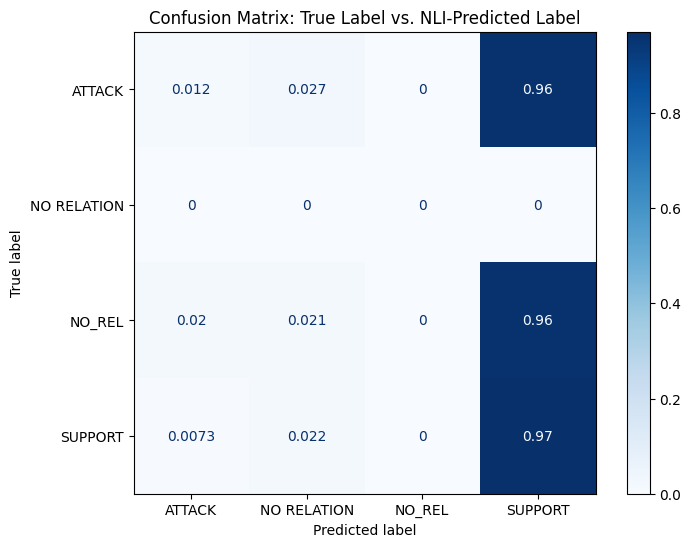

2025-12-21 04:31:59,743 - INFO - --- NLI Analysis Complete ---
INFO:__main__:--- NLI Analysis Complete ---
2025-12-21 04:31:59,791 - INFO - 
========== SEMANTIC ANALYSIS COMPLETE ==========
INFO:__main__:
========== SEMANTIC ANALYSIS COMPLETE ==========
2025-12-21 04:31:59,792 - INFO - NLI3 sample results saved to 'results_with_nli3_sample.csv'
INFO:__main__:NLI3 sample results saved to 'results_with_nli3_sample.csv'


In [11]:
# ==============================================================================
# === 6.1 NLI3 EXECUTION
# ==============================================================================

if __name__ == '__main__':
    config = AnalysisConfig()
    logger.info(f"Using device: {config.DEVICE}")
    
    # 1. Load full dataset
    full_df = load_full_data(config)
    
    if full_df is not None:
        
        # --- Run NLI Analysis ---
        # This is slow and runs on a sample
        logger.info(f"Creating a random sample of {config.NLI_SAMPLE_SIZE} pairs for NLI analysis.")
        df_sample = full_df.sample(n=config.NLI_SAMPLE_SIZE, random_state=42)
        
        df_sample_with_nli = perform_nli_analysis3(
            df_sample, 
            config.NLI_MODEL, 
            config
        )
        
        # 6. Save results
        df_sample_with_nli.to_csv("results_with_nli3_sample.csv", index=False)
        
        logger.info("\n========== SEMANTIC ANALYSIS COMPLETE ==========")
        logger.info("NLI3 sample results saved to 'results_with_nli3_sample.csv'")
        
    else:
        logger.error("Failed to load data. Exiting.")